# โครงงาน Thai Character Classifier: การจำแนกตัวอักษรไทย
**เป้าหมาย:** พัฒนาแบบจำลอง Machine Learning (CNN) สำหรับจำแนกประเภทภาพตัวอักษรไทยและสัญลักษณ์ต่างๆ รวม 95 คลาส

**ชุดข้อมูล:** PimAksornThai (ดาวน์โหลดจาก Kaggle) ประกอบด้วยภาพตัวอักษรที่สร้างจากฟอนต์ 406 แบบ จำนวนกว่า 38,570 ภาพ

**สิทธิ์การใช้งาน:** Attribution 4.0 International (CC BY 4.0)


In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random

In [3]:
DATASET_PATH = '../datasets' 

class_paths = []
image_counts = {}

for root, dirs, files in os.walk(DATASET_PATH):
    images = [f for f in files if f.endswith(('.png', '.jpg', '.jpeg'))]
    if images:
        class_name = os.path.basename(root)
        class_paths.append(root)
        image_counts[class_name] = len(images)

print(f"ค้นพบข้อมูลทั้งหมด: {len(image_counts)} คลาส")
print(f"จำนวนรูปภาพรวม: {sum(image_counts.values())} ภาพ")

ค้นพบข้อมูลทั้งหมด: 95 คลาส
จำนวนรูปภาพรวม: 38570 ภาพ


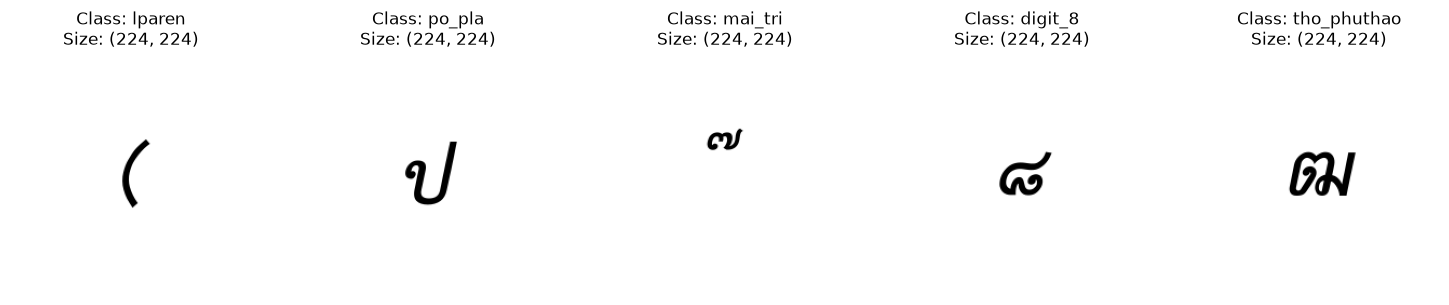

In [4]:
sample_classes = random.sample(class_paths, 5)

plt.figure(figsize=(15, 3))
for i, path in enumerate(sample_classes):
    class_name = os.path.basename(path)
    img_name = [f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))][0]
    img_path = os.path.join(path, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {class_name}\nSize: {img.size}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 64
X = [] 
y = [] 

print("กำลังโหลดและประมวลผลรูปภาพ กรุณารอสักครู่...")

for path in class_paths:
    class_name = os.path.basename(path)
    images = [f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    for file in images:
        img_path = os.path.join(path, file)
        try:
            img = Image.open(img_path).convert('L')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            
            img_array = np.array(img) / 255.0
            
            X.append(img_array)
            y.append(class_name)
        except Exception as e:
            print(f"ข้ามไฟล์ที่อ่านไม่ได้: {img_path}")

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
NUM_CLASSES = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("การเตรียมข้อมูลเสร็จสมบูรณ์!")
print(f"ข้อมูลชุด Train: {X_train.shape}")
print(f"ข้อมูลชุด Test: {X_test.shape}")

กำลังโหลดและประมวลผลรูปภาพ กรุณารอสักครู่...
การเตรียมข้อมูลเสร็จสมบูรณ์!
ข้อมูลชุด Train: (30856, 64, 64, 1)
ข้อมูลชุด Test: (7714, 64, 64, 1)


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 95)             │        24,415 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,991 (4.95 MB)

 Trainable params: 1,296,991 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("เริ่มการฝึกแบบจำลอง...")

history = model.fit(
    X_train, y_train, 
    epochs=10, 
    validation_data=(X_test, y_test),
    batch_size=32
)

เริ่มการฝึกแบบจำลอง...
Epoch 1/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - accuracy: 0.3326 - loss: 2.5046 - val_accuracy: 0.7794 - val_loss: 0.7021
Epoch 2/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.7085 - loss: 0.8733 - val_accuracy: 0.8807 - val_loss: 0.3689
Epoch 3/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.8002 - loss: 0.6007 - val_accuracy: 0.9006 - val_loss: 0.2842
Epoch 4/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.8359 - loss: 0.4909 - val_accuracy: 0.9135 - val_loss: 0.2481
Epoch 5/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - accuracy: 0.8587 - loss: 0.4151 - val_accuracy: 0.9244 - val_loss: 0.2194
Epoch 6/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.8745 - loss: 0.3657 - val_accuracy: 0.9341 - val_loss: 0.1948
Epoch 7/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - accuracy: 0.8873 - loss: 0.3312 - val_accuracy: 0.9292 - val_loss: 0.2053
Epoch 8/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - accuracy: 0